In [36]:
# only pandas is required
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Dataset/DataCoSupplyChainDataset.csv', encoding_errors='ignore')
df.shape

(180519, 53)

In [3]:
def rename_col(s): #assumed to be a column name
    s = s.replace(' ', '_')
    s = s.replace('-', '_')
    s = s.replace('(', '')
    s = s.replace(')', '')
    a = s.split('_')
    for i in range(len(a)):  # iterates through each word in the list a
        if not all([c == c.upper() for c in a[i]]): # Capitalizing the first letter of each word (unless the entire word is in uppercase
            a[i] = a[i].capitalize()
    return '_'.join(a)

df.columns = [rename_col(c) for c in df.columns]
df.columns

Index(['Type', 'Days_For_Shipping_Real', 'Days_For_Shipment_Scheduled',
       'Benefit_Per_Order', 'Sales_Per_Customer', 'Delivery_Status',
       'Late_Delivery_Risk', 'Category_Id', 'Category_Name', 'Customer_City',
       'Customer_Country', 'Customer_Email', 'Customer_Fname', 'Customer_Id',
       'Customer_Lname', 'Customer_Password', 'Customer_Segment',
       'Customer_State', 'Customer_Street', 'Customer_Zipcode',
       'Department_Id', 'Department_Name', 'Latitude', 'Longitude', 'Market',
       'Order_City', 'Order_Country', 'Order_Customer_Id',
       'Order_Date_Dateorders', 'Order_Id', 'Order_Item_Cardprod_Id',
       'Order_Item_Discount', 'Order_Item_Discount_Rate', 'Order_Item_Id',
       'Order_Item_Product_Price', 'Order_Item_Profit_Ratio',
       'Order_Item_Quantity', 'Sales', 'Order_Item_Total',
       'Order_Profit_Per_Order', 'Order_Region', 'Order_State', 'Order_Status',
       'Order_Zipcode', 'Product_Card_Id', 'Product_Category_Id',
       'Product_Descript

In [4]:
df.head()

,Type,Days_For_Shipping_Real,Days_For_Shipment_Scheduled,Benefit_Per_Order,Sales_Per_Customer,Delivery_Status,Late_Delivery_Risk,Category_Id,Category_Name,Customer_City,...,Order_Zipcode,Product_Card_Id,Product_Category_Id,Product_Description,Product_Image,Product_Name,Product_Price,Product_Status,Shipping_Date_Dateorders,Shipping_Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


# What are the sales trends over time?¶
Analyze how sales fluctuate monthly or yearly to understand seasonality and growth trends in the dataset.



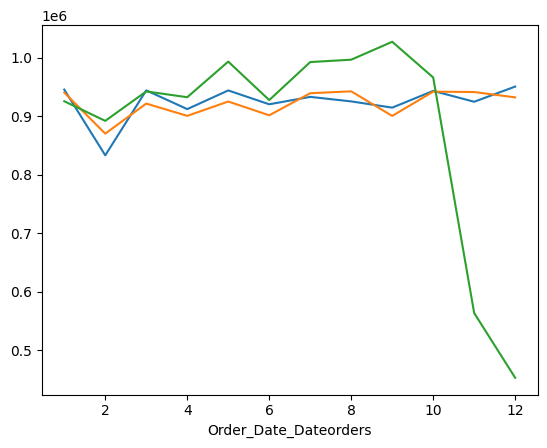

In [5]:
#  time-series analysis of sales per customer, grouping the data by month for each year from 2015 to 2017
df.Order_Date_Dateorders = pd.to_datetime(df.Order_Date_Dateorders)

for year in range(2015, 2018):
    group = df[df.Order_Date_Dateorders.dt.year == year].groupby(df.Order_Date_Dateorders.dt.to_period('M')).Sales_Per_Customer.sum() #for each month within the current year
    group.index = group.index.month # extracts the month number
    group.plot(kind='line')

# How does shipping duration (real vs. scheduled) affect customer satisfaction or delivery status?
Investigate whether delays beyond the scheduled shipping time correlate with delivery statuses like 'Late delivery' or 'Advance shipping

Shipping_Duration_Difference    Axes(0.125,0.11;0.775x0.77)
dtype: object

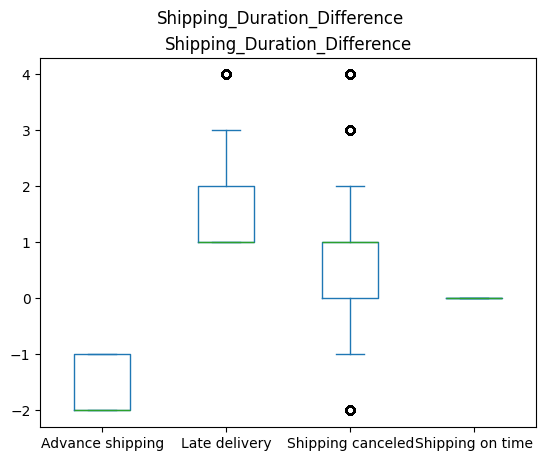

In [6]:
df['Shipping_Duration_Difference'] = df.Days_For_Shipping_Real - df.Days_For_Shipment_Scheduled
df.plot.box(by='Delivery_Status', column='Shipping_Duration_Difference', title='Shipping_Duration_Difference') 

# What is the relationship between product category and sales performance?
Determine which categories perform best in terms of sales and profitability.

Text(0.5, 1.0, 'Top 10 Category Performance')

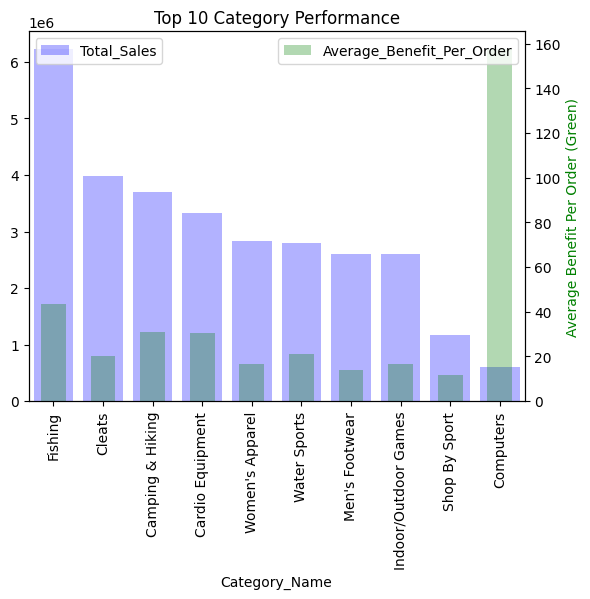

In [41]:
category_performance = df.groupby('Category_Name').agg(
    Total_Sales=('Sales_Per_Customer', 'sum'),
    Average_Benefit_Per_Order=('Benefit_Per_Order', 'mean')
)

category_performance = category_performance.sort_values(by='Total_Sales', ascending=False)
ax1 = category_performance.Total_Sales.head(10).plot(kind='bar', width=0.8, color='blue', alpha=0.3)
ax2 = ax1.twinx()
category_performance.Average_Benefit_Per_Order.head(10).plot(kind='bar', color='green', width=0.5, alpha=0.3, ax=ax2)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
# Set labels and title
plt.xlabel("Category Name")
plt.ylabel("Total Sales (Blue)", color='blue')
ax2.set_ylabel("Average Benefit Per Order (Green)", color='green')
plt.title("Top 10 Category Performance")

Text(0.5, 1.0, 'Top 10 Category Performance: Total Sales vs. Average Benefit')

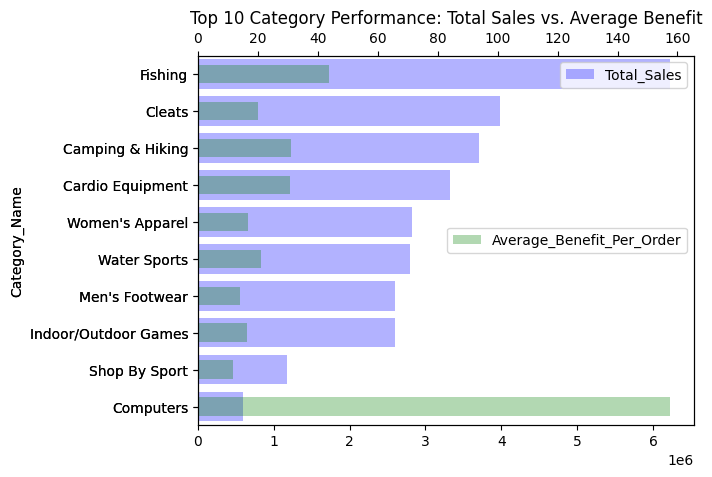

In [46]:
category_performance = df.groupby('Category_Name').agg(
    Total_Sales=('Sales_Per_Customer', 'sum'),
    Average_Benefit_Per_Order=('Benefit_Per_Order', 'mean')
)

category_performance = category_performance.sort_values(by='Total_Sales', ascending=False)

ax1 = category_performance.Total_Sales.head(10).plot(kind='barh', width=0.8, color='blue', alpha=0.3)
ax2 = ax1.twiny()
category_performance.Average_Benefit_Per_Order.head(10).plot(kind='barh', color='green', width=0.5, alpha=0.3, ax=ax2)

ax1.invert_yaxis()
#ax3.invert_yaxis()

ax1.legend(loc='upper right')
ax2.legend(loc='right')

plt.title("Top 10 Category Performance: Total Sales vs. Average Benefit" )

Text(0.5, 1.0, 'Top 10 Category Performance: Average Benefit vs. Total Sales')

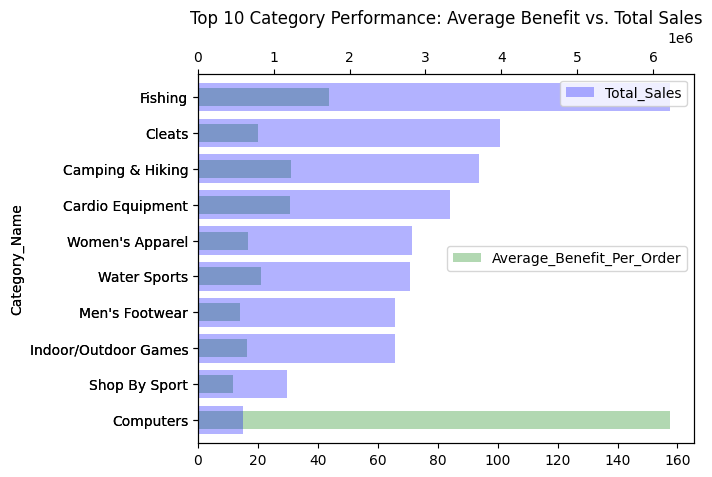

In [47]:
category_performance = df.groupby('Category_Name').agg(
    Total_Sales=('Sales_Per_Customer', 'sum'),
    Average_Benefit_Per_Order=('Benefit_Per_Order', 'mean')
)

category_performance = category_performance.sort_values(by='Total_Sales', ascending=False)

ax1 = category_performance.Average_Benefit_Per_Order.head(10).plot(kind='barh', color='green', width=0.5, alpha=0.3)
ax2 = ax1.twiny()
category_performance.Total_Sales.head(10).plot(kind='barh', width=0.8, color='blue', alpha=0.3, ax=ax2)

ax1.invert_yaxis()

ax1.legend(loc='right')
ax2.legend(loc='upper right')

plt.title("Top 10 Category Performance: Average Benefit vs. Total Sales")

# Which cities or regions have the highest sales and why?
Explore geographical patterns in sales to identify key markets and potential areas for expansion.

Text(0.5, 1.0, 'Top 10 Cities by Total Sales Per Customer')

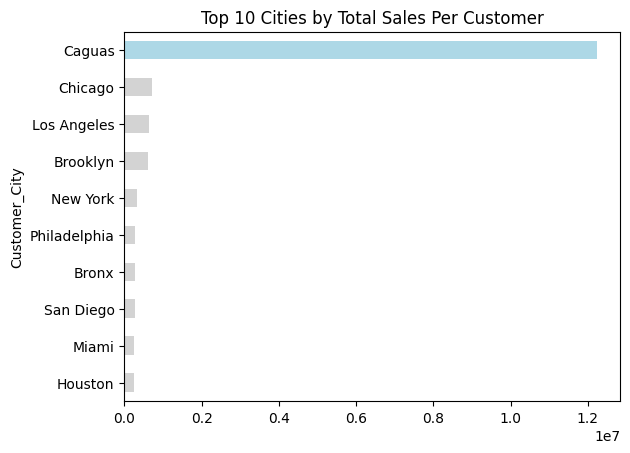

In [51]:
ax = df.groupby('Customer_City').Sales_Per_Customer.sum().sort_values(ascending=False).head(10).sort_values().plot(kind='barh', color='lightgray')
bars = ax.patches
bars[-1].set_facecolor('lightblue')

plt.title("Top 10 Cities by Total Sales Per Customer")

Text(0.5, 1.0, 'Top 10 Countries by Total Sales Per Customer')

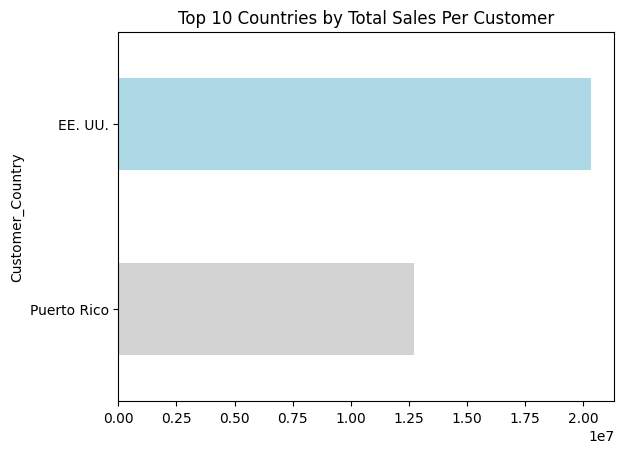

In [49]:
ax = df.groupby('Customer_Country').Sales_Per_Customer.sum().sort_values(ascending=False).head(10).sort_values().plot(kind='barh', color='lightgray')
bars = ax.patches
bars[-1].set_facecolor('lightblue')

plt.title("Top 10 Countries by Total Sales Per Customer")

# What is the impact of different payment types on sales and delivery efficiency?
Explore how payment methods like DEBIT, TRANSFER, CASH, and others influence the overall sales process and delivery times.

Text(0.5, 1.0, 'Delivery Status Count by Type')

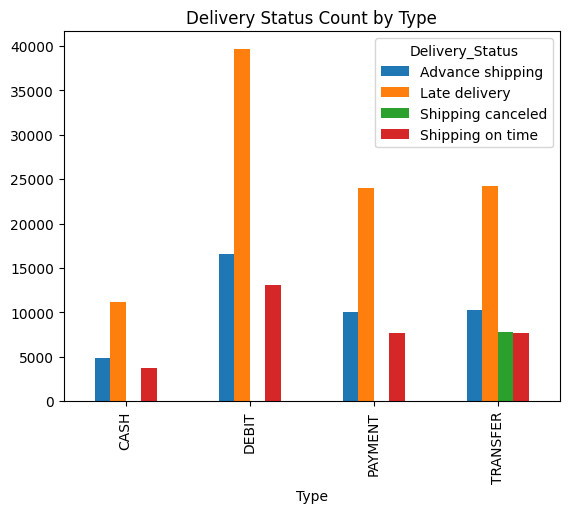

In [52]:
group = df.groupby(['Type', 'Delivery_Status']).Type.count().unstack()
group.plot(kind='bar')

plt.title("Delivery Status Count by Type")

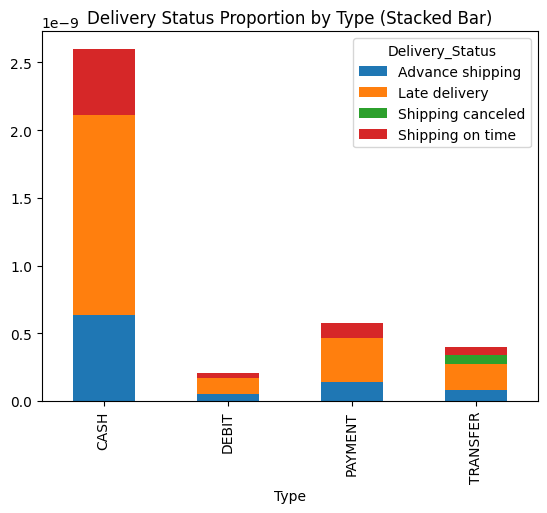

In [55]:
group['Total'] = group.sum(axis=1)
for c in group.columns[:-1]:
    group[c] = group[c] / group.Total
group[group.columns[:-1]].plot(kind='bar', stacked=True)

# Add title
plt.title("Delivery Status Proportion by Type (Stacked Bar)")

plt.show()

# What are the characteristics of high-risk orders in terms of late delivery?
Identify common factors in orders that have a higher risk of late delivery, potentially guiding improvements in logistics.

# How does the benefit per order vary across different product categories and customer segments?
Analyze profitability by different categories and customer demographics to optimize product mix and promotional strategies.

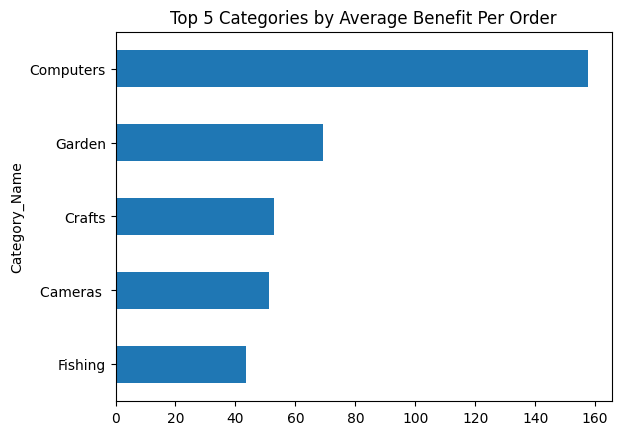

In [57]:
df.groupby('Category_Name').Benefit_Per_Order.mean().sort_values(ascending=False).head().sort_values().plot(kind='barh')

plt.title("Top 5 Categories by Average Benefit Per Order")

plt.show()

# What is the rate of return or cancellation across product categories?¶
Understanding return rates can help in assessing product quality or customer satisfaction by category.

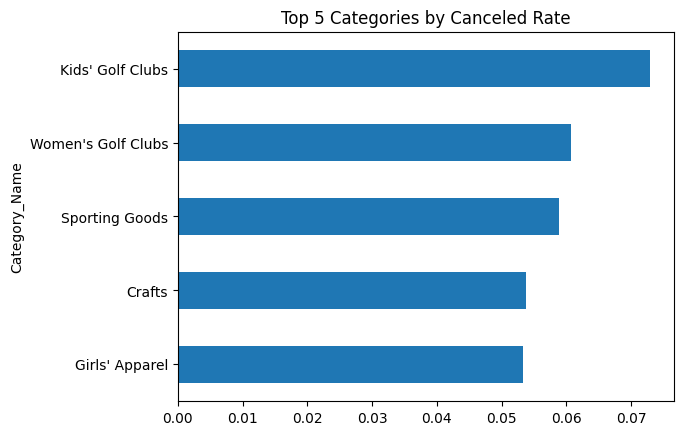

In [58]:
group = df.groupby(['Category_Name','Delivery_Status']).Category_Name.count().unstack()
group['Total'] = group.sum(axis=1)
group['Canceled_Rate'] = group['Shipping canceled'] / group.Total
ax = group.Canceled_Rate.sort_values(ascending=False).head().plot(kind='barh', title='Canceled_Rate')
ax.invert_yaxis()

plt.title("Top 5 Categories by Canceled Rate")

plt.show()

# Which shipping modes are most effective in terms of cost and delivery time?
Compare shipping modes like 'Standard Class', 'First Class', 'Second Class', etc., to determine their efficiency and impact on customer satisfaction.

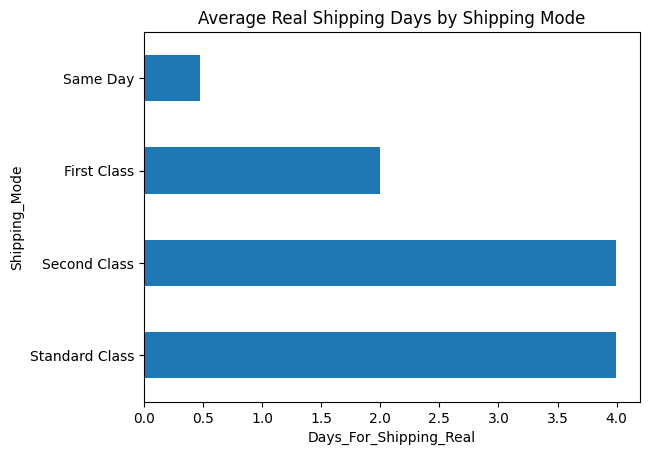

In [59]:
df.groupby('Shipping_Mode').Days_For_Shipping_Real.mean().sort_values(ascending=False).plot(kind='barh', xlabel='Days_For_Shipping_Real')

plt.title("Average Real Shipping Days by Shipping Mode")

plt.show()

# How do seasonal factors and holidays affect sales and shipping performance?
Look into sales peaks and troughs around major holidays and seasons to better plan inventory and staffing.

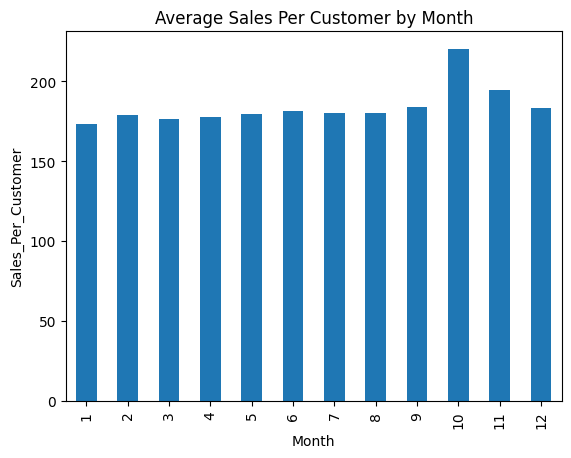

In [60]:
df.groupby(df.Order_Date_Dateorders.dt.month).Sales_Per_Customer.mean().plot(kind='bar', xlabel='Month', ylabel='Sales_Per_Customer')

plt.title("Average Sales Per Customer by Month")

plt.show()

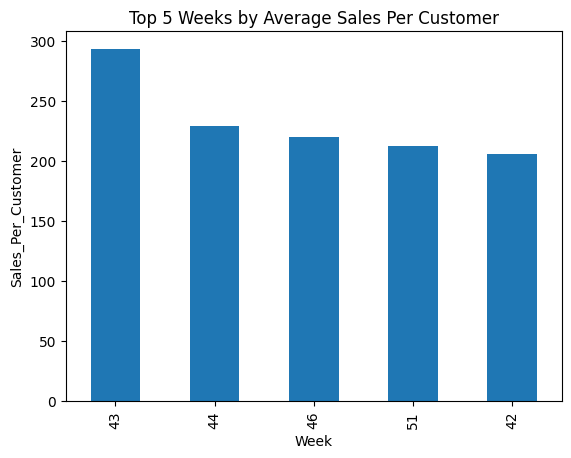

In [61]:
df.groupby(df.Order_Date_Dateorders.dt.isocalendar().week).Sales_Per_Customer.mean().sort_values(ascending=False).head().plot(kind='bar', xlabel='Week', ylabel='Sales_Per_Customer')

plt.title("Top 5 Weeks by Average Sales Per Customer")

plt.show()

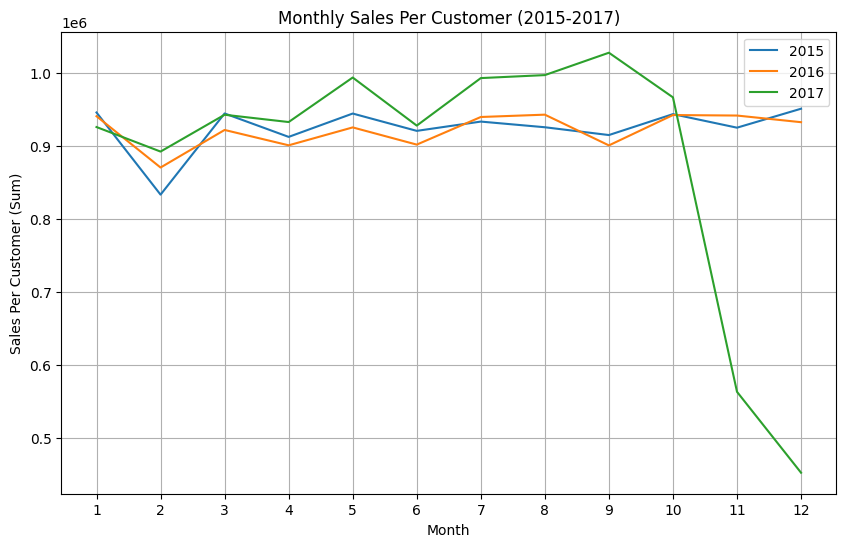

In [37]:
plt.figure(figsize=(10, 6))

for year in range(2015, 2018):
    group = df[df.Order_Date_Dateorders.dt.year == year].groupby(df.Order_Date_Dateorders.dt.to_period('M')).Sales_Per_Customer.sum()
    group.index = group.index.month
    sns.lineplot(x=group.index, y=group.values, label=str(year))

plt.xlabel("Month")
plt.ylabel("Sales Per Customer (Sum)")
plt.title("Monthly Sales Per Customer (2015-2017)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

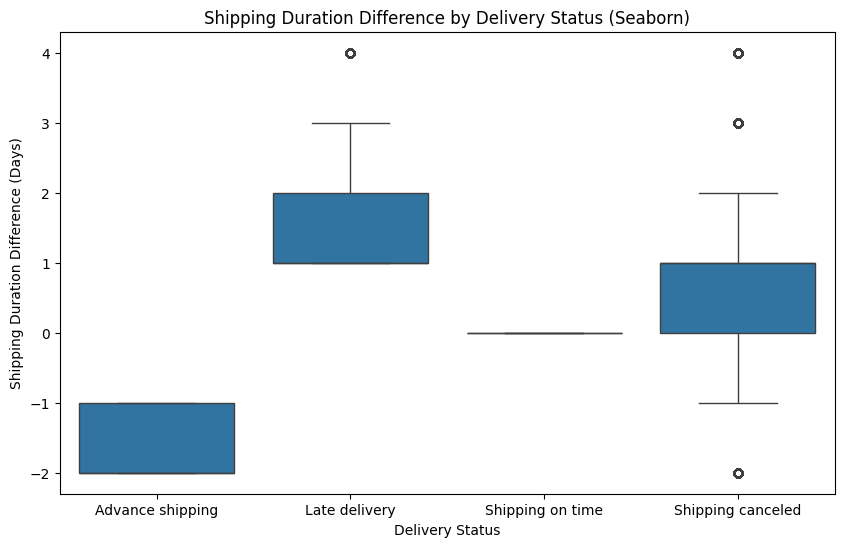

In [38]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Delivery_Status', y='Shipping_Duration_Difference', data=df)
plt.title('Shipping Duration Difference by Delivery Status (Seaborn)')
plt.xlabel('Delivery Status')
plt.ylabel('Shipping Duration Difference (Days)')
plt.show()

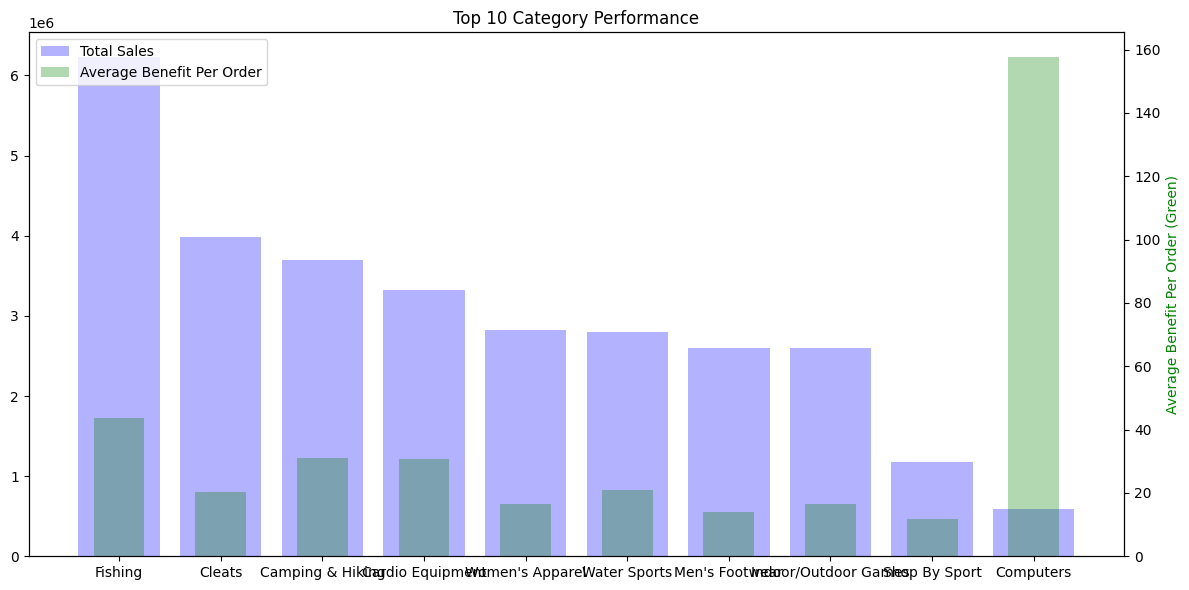

In [39]:
category_performance = df.groupby('Category_Name').agg(
    Total_Sales=('Sales_Per_Customer', 'sum'),
    Average_Benefit_Per_Order=('Benefit_Per_Order', 'mean')
)

category_performance = category_performance.sort_values(by='Total_Sales', ascending=False)

# Matplotlib approach:
plt.figure(figsize=(12, 6))  # Adjust figure size as needed

# First bar plot (Total Sales)
ax1 = plt.bar(category_performance.head(10).index, category_performance.Total_Sales.head(10), width=0.8, color='blue', alpha=0.3)

# Second bar plot (Average Benefit Per Order) - on the same figure with twin axes
ax2 = plt.twinx()  # Create a twin Axes sharing the x-axis
ax2.bar(category_performance.head(10).index, category_performance.Average_Benefit_Per_Order.head(10), width=0.5, color='green', alpha=0.3)

# Add legends
plt.legend([ax1, ax2.patches[0]], ['Total Sales', 'Average Benefit Per Order'], loc='upper left')

# Set labels and title
plt.xlabel("Category Name")
plt.ylabel("Total Sales (Blue)", color='blue')
ax2.set_ylabel("Average Benefit Per Order (Green)", color='green')
plt.title("Top 10 Category Performance")

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability

plt.tight_layout() # Adjust layout to prevent clipping of labels
plt.show()